# Image Processing Notebook: Plot the H Cross-Section (from Transmission)


This notebook takes the processed transmission imagesand plot the H Cross-sections from specific ROIs

## Initial Settings

### Import Libraries

In [1]:
import sys
sys.path.append(r'..\01_Functions')
from step_functions import *
from dict_functions import *
from proc_functions import *
from img_functions import *
from plotting_cs import *
from cross_sections import *
import seaborn as sns
%matplotlib inline
pd.set_option('display.max_rows', 20)

### Provide Directories

#### Provide the directory for transmission images

In [2]:
# %load select_directory('ref_dir')
ref_dir = r"J:\700 Campaigns - internal\2022\PSI22_04NI\00_Processed\01_Transmission_results\000_exp2000\00_empty_ref02"

In [3]:
src_dir = r"J:\700 Campaigns - internal\2022\PSI22_04NI\00_Processed\01_Transmission_results\000_exp1000\00_LP30_pristine"

#### Provide the Spectra.txt file from any of the experiments. 
These are the neutron arrival times the MCP detected

In [4]:
# %load select_file('spectra_file')
spectra_file = r"J:\700 Campaigns - internal\2022\PSI22_04NI\Raw_images\exp2000\exp2200_LP40_deg\02_pos00\IMAT00018918_02_pos00_001_Spectra.txt"

#### Provide the directory for saving results

In [5]:
# %load select_directory('dst_dir')
dst_dir = r"J:\700 Campaigns - internal\2022\PSI22_04NI\00_Processed\02_Cross_sections_results\000_exp1000"

### Read the directory and extract values from images
You can specify a single folder but if you want all the folders in the `src_dir`, leave `proc_folder=[]`.

In [6]:
src_dict = read_saved_dict (src_dir, proc_folder = [])
ref_dict = read_saved_dict (ref_dir, proc_folder = [])

Reading Images: 100%|████████████████████████████| 5/5 [00:00<00:00,  8.31it/s]


#### Extract an averaged image for each key
For each `proc_folder` (acquisition), an averaged image will be extracted

In [7]:
avg_imgs = []
for key, value in ref_dict.items():
    img =  avg_frames_dict (value, output_type = 'img', start_img = 15, end_slice = 20)
    avg_imgs.append(img[0])

#### Select the ROIs
For simplicity handling the names, `ROIs_` before the name of the `proc_folder` is required

In [8]:
# %load select_multiple_rois(proc_folder[0], avg_images[0], cmap = 'flag')

# from each chip region LP30 pristine
ROIs_02_pos00 = [[146, 35, 78, 69], [33, 35, 78, 69], [32, 154, 78, 69], [145, 152, 78, 69]]
ROIs_04_pos01 = [[146, 35, 78, 69], [33, 35, 78, 69], [32, 154, 78, 38], [145, 152, 78, 40]] #
ROIs_06_pos02 = [[146, 35, 78, 69], [33, 35, 78, 69], [32, 154, 78, 69], [145, 152, 78, 69]]
ROIs_08_pos03 = [[146, 35, 78, 69], [33, 35, 78, 69], [32, 154, 78, 69], [145, 152, 78, 69]]
ROIs_10_pos04 = [[146, 35, 78, 69], [33, 35, 78, 69], [32, 154, 78, 69], [145, 152, 78, 69]]

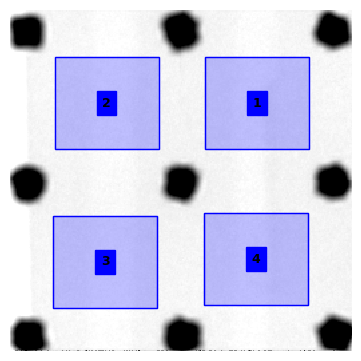

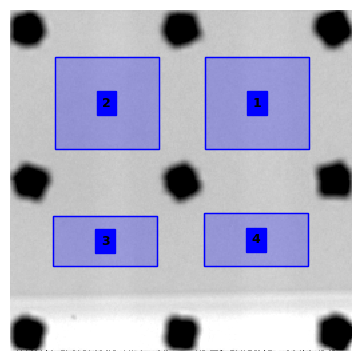

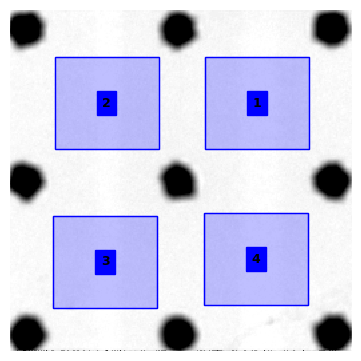

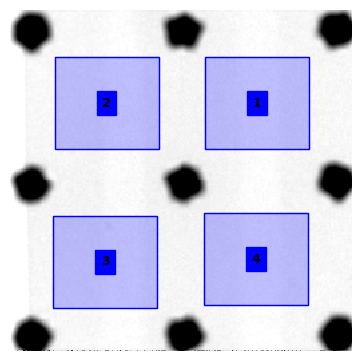

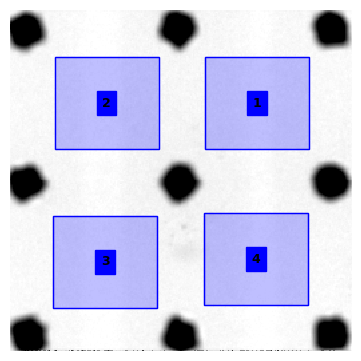

In [9]:
show_img(avg_imgs[0], dr = [(ROIs_02_pos00, 'blue')], cmap='gray', nrows=3, ncols=2, index=1)
show_img(avg_imgs[1], dr = [(ROIs_04_pos01, 'blue')], cmap='gray', nrows=3, ncols=2, index=2)
show_img(avg_imgs[2], dr = [(ROIs_06_pos02, 'blue')], cmap='gray', nrows=3, ncols=2, index=3)
show_img(avg_imgs[3], dr = [(ROIs_08_pos03, 'blue')], cmap='gray', nrows=3, ncols=2, index=4)
show_img(avg_imgs[4], dr = [(ROIs_10_pos04, 'blue')], cmap='gray', nrows=3, ncols=2, index=5)

#### Create a dictionary of the ROIs

In [10]:
rois_dict = {}
for name in ref_dict.keys():
    rois_name = 'ROIs_'+ name
    for rois in [rois_name]:
        rois_dict[rois] = eval(rois)

### Extract the values

In [11]:
ref_vals = get_roi_values (ref_dict, rois_dict, spectra_file, save_path = dst_dir, binning = 20, 
                                 flight_path = 56, start_slice = 0, name_xlsx = 'Roi_values_auto.xlsx', 
                                 save_results = False)

In [12]:
img_vals = get_roi_values (src_dict, rois_dict, spectra_file, save_path = dst_dir, binning = 20, 
                                 flight_path = 56, start_slice = 0, name_xlsx = 'Roi_values_auto.xlsx', 
                                 save_results = False)

In [13]:
data_wvl = img_vals['Wavelength [Å]']

ref_vals = ref_vals.loc[2:36]
ref_vals = ref_vals.reset_index(drop=True)

img_vals = img_vals.loc[2:36]
img_vals = img_vals.reset_index(drop=True)

In [14]:
trans_rois = prepare_trans_data(img_vals, data_ref = ref_vals, data_output = 'transmission')

In [15]:
trans_rois

,Wavelength [Å],Transmission_02_pos00_roi_1,Transmission_02_pos00_roi_2,Transmission_02_pos00_roi_3,Transmission_02_pos00_roi_4,Transmission_04_pos01_roi_1,Transmission_04_pos01_roi_2,Transmission_04_pos01_roi_3,Transmission_04_pos01_roi_4,Transmission_06_pos02_roi_1,...,Transmission_06_pos02_roi_3,Transmission_06_pos02_roi_4,Transmission_08_pos03_roi_1,Transmission_08_pos03_roi_2,Transmission_08_pos03_roi_3,Transmission_08_pos03_roi_4,Transmission_10_pos04_roi_1,Transmission_10_pos04_roi_2,Transmission_10_pos04_roi_3,Transmission_10_pos04_roi_4
0,1.279359,0.879431,0.876548,0.874423,0.872917,0.883947,0.879627,0.882312,0.875224,0.883544,...,0.881979,0.877487,0.877523,0.880981,0.880771,0.878114,0.883298,0.886882,0.885383,0.888445
1,1.531952,0.868644,0.868083,0.872850,0.870389,0.876708,0.874564,0.874685,0.873582,0.872060,...,0.874933,0.875300,0.875344,0.871262,0.875824,0.870985,0.876839,0.878574,0.882376,0.882606
2,1.776463,0.861261,0.861702,0.862883,0.859884,0.865611,0.864864,0.864114,0.863131,0.861795,...,0.865914,0.864660,0.863746,0.862937,0.867568,0.863964,0.868006,0.870886,0.870452,0.872507
3,2.032233,0.854298,0.855530,0.855743,0.853129,0.860501,0.859522,0.858741,0.856976,0.854107,...,0.858213,0.858995,0.855151,0.854537,0.857008,0.855906,0.860929,0.862610,0.864269,0.864947
4,2.304880,0.851547,0.851790,0.853276,0.848163,0.856782,0.853733,0.853274,0.851519,0.849132,...,0.852195,0.853596,0.851053,0.848691,0.851965,0.851321,0.851088,0.853757,0.854206,0.854577
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
30,8.806118,0.726016,0.725093,0.722524,0.719931,0.736835,0.729004,0.715970,0.716117,0.744704,...,0.741879,0.739642,0.737277,0.722220,0.728555,0.732755,0.721933,0.734216,0.737515,0.735902
31,9.039954,0.729980,0.730290,0.722240,0.719098,0.739598,0.743732,0.719242,0.728316,0.719050,...,0.730140,0.728390,0.725351,0.710053,0.713254,0.720595,0.722249,0.726271,0.732876,0.727168
32,9.271439,0.718854,0.706500,0.717035,0.713302,0.734247,0.737420,0.707000,0.713295,0.724266,...,0.730841,0.719805,0.727351,0.712347,0.715227,0.727501,0.729587,0.730291,0.731207,0.720591
33,9.525303,0.711007,0.702670,0.706936,0.714814,0.716966,0.718838,0.704852,0.704061,0.702218,...,0.721522,0.704624,0.710686,0.707377,0.698722,0.718943,0.726396,0.718249,0.724663,0.718462


### Get the transmission table
If the images given before are transmission, leave empty the data_ref in the `prepare_trans_data` function. 
If not, run the previous line but with the reference images directory.

Depending on the **data_output** chosen ('transmission'. 'optical density', 'total cs', or 'h cs'). if the requested data is `total cs` or `h cs`, a dictionary of compounds is required. This is basically a list of the material expected **in oder** from the ROIs given before.

The  full dictionary of cross-sections is located at the top of the `plotting_cs` function. In the notebook, we are using only those that are required to avoid clogging the information.

### H cross section parameters

In [16]:
thickness = 0.061

ec = {'abbv': 'EC', 'composition' : {'C':3.0, 'H':4.0, 'O':3.0},'density':1.32, 'thickness': thickness}
dmc = {'abbv': 'DMC','composition' : {'C':3.0, 'H':6.0, 'O':3.0}, 'density':1.07, 'thickness': thickness}
dec = {'abbv': 'DEC','composition' : {'C':5.0, 'H':10.0, 'O':3.0}, 'density':0.975, 'thickness': thickness}
lipf6 = {'abbv': 'LiPF6','composition' : {'LI':1.0, 'P':1.0, 'F':6.0}, 'density':1.5, 'thickness': thickness}
ec_dmc_11v = {'abbv': 'EC_DMC (1:1v)','molecules' : [ec,0.5,dmc,0.5], 'density':1.28, 'thickness': thickness}
ec_dec_11v = {'abbv': 'EC_DEC (1:1v)','molecules' : [ec,0.5,dec,0.5], 'density':1.1785, 'thickness': thickness}
#lp30 = {'abbv': 'LP30','molecules' : [ec, 0.406359477,dmc, 0.501683056, lipf6, 0.091957467], 'density':1.2795, 'thickness': thickness}
#lp40 = {'abbv': 'LP40','molecules' : [ec, 0.447925137,dec, 0.447925137, lipf6, 0.104149725], 'density':1.2635, 'thickness': thickness}

lp30 = {'abbv': 'LP30','molecules' : [ec, 0.446003162,dmc, 0.446003162, lipf6, 0.107993676], 'density':1.2284, 'thickness': thickness}
lp40 = {'abbv': 'LP40','molecules' : [ec, 0.447925137,dec, 0.447925137, lipf6, 0.104149725], 'density':1.1847, 'thickness': thickness}



## exp1000 -> LP30


In [17]:
compounds_dict = [lp30, lp30, lp30, lp30, lp30, lp30, lp30, lp30, lp30, lp30,
                 lp30, lp30, lp30, lp30, lp30, lp30, lp30, lp30, lp30, lp30]

### Get the cross sections
Function to get the cross sections, the requested_cs is a list of the desired cross-sections options are ['total_cs','h_cs','li_cs']

In [18]:
res_data = prepare_trans_data(trans_rois, data_output = 'h cs', compounds_dict = compounds_dict)

Data_imgs variable taken as transmission images


**it was determined that an interpolation via Savgol of 5,2 does not affect the outcome but improves the data visualization. Therefore, it was kept**

In [19]:
#save_DF (dst_dir, res_data, df_name = '00_LP30_H_CS_pristine.xlsx', sheet_name = 'no_interp_lp30', mode = 'a')

In [20]:
res_data = dataframe_to_savgol(res_data, 5, 2)

In [ ]:
save_DF (dst_dir, res_data, df_name = '00_LP30_H_CS.xlsx', sheet_name = 'H_CS_061', mode = 'a')

In [21]:
    # position column name extraction
pos00 = [column for column in res_data if 'pos00' in column]
pos01 = [column for column in res_data if 'pos01' in column]
pos02 = [column for column in res_data if 'pos02' in column]
pos03 = [column for column in res_data if 'pos03' in column]
pos04 = [column for column in res_data if 'pos04' in column]
    # recalling the data with the specified columns and the wavelength column up front
cs_pos00_dat = pd.concat([data_wvl, res_data[pos00]], axis = 1)
cs_pos01_dat = pd.concat([data_wvl, res_data[pos01]], axis = 1)
cs_pos02_dat = pd.concat([data_wvl, res_data[pos02]], axis = 1)
cs_pos03_dat = pd.concat([data_wvl, res_data[pos03]], axis = 1)
cs_pos04_dat = pd.concat([data_wvl, res_data[pos04]], axis = 1)

avg_vals_dat = pd.DataFrame(data_wvl)
avg_vals_dat ['pos00'] = cs_pos00_dat.iloc[:,1:].mean(axis=1)
avg_vals_dat ['pos01'] = cs_pos01_dat.iloc[:,1:].mean(axis=1)
avg_vals_dat ['pos02'] = cs_pos02_dat.iloc[:,1:].mean(axis=1)
avg_vals_dat ['pos03'] = cs_pos03_dat.iloc[:,1:].mean(axis=1)
avg_vals_dat ['pos04'] = cs_pos04_dat.iloc[:,1:].mean(axis=1)

In [22]:
cs_pos00_dat=cs_pos00_dat.melt('Wavelength [Å]', var_name='val', value_name='cross-section [barns]')
cs_pos01_dat=cs_pos01_dat.melt('Wavelength [Å]', var_name='val', value_name='cross-section [barns]')
cs_pos02_dat=cs_pos02_dat.melt('Wavelength [Å]', var_name='val', value_name='cross-section [barns]')
cs_pos03_dat=cs_pos03_dat.melt('Wavelength [Å]', var_name='val', value_name='cross-section [barns]')
cs_pos04_dat=cs_pos04_dat.melt('Wavelength [Å]', var_name='val', value_name='cross-section [barns]')
avg_vals_dat=avg_vals_dat.melt('Wavelength [Å]', var_name='val', value_name='cross-section [barns]')

In [23]:
#sns.relplot(data = cs_pos01_dat, x = 'Wavelength [Å]', y = 'cross-section [barns]', hue = 'val', 
#            kind = 'line', legend = 'brief', height=6, aspect=1.2)

<AxesSubplot:xlabel='Wavelength [Å]', ylabel='cross-section [barns]'>

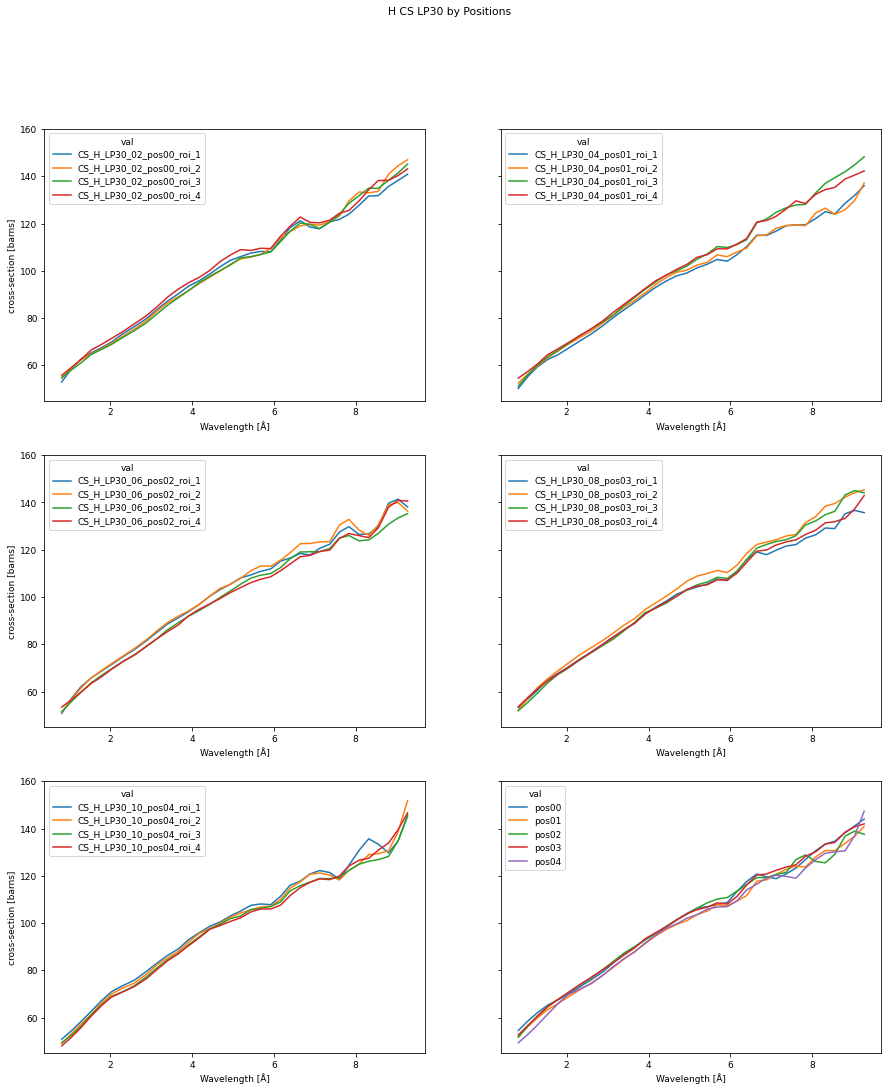

In [33]:
fig0, ax = plt.subplots(3,2, figsize = (15,17), sharey = True)
fig0.suptitle('H CS LP30 by Positions')
plt.ylim([45,160])
sns.lineplot(ax = ax[0,0], data = cs_pos00_dat, x = 'Wavelength [Å]', y = 'cross-section [barns]', hue = 'val')
sns.lineplot(ax = ax[0,1], data = cs_pos01_dat, x = 'Wavelength [Å]', y = 'cross-section [barns]', hue = 'val')
sns.lineplot(ax = ax[1,0], data = cs_pos02_dat, x = 'Wavelength [Å]', y = 'cross-section [barns]', hue = 'val')
sns.lineplot(ax = ax[1,1], data = cs_pos03_dat, x = 'Wavelength [Å]', y = 'cross-section [barns]', hue = 'val')
sns.lineplot(ax = ax[2,0], data = cs_pos04_dat, x = 'Wavelength [Å]', y = 'cross-section [barns]', hue = 'val')
sns.lineplot(ax = ax[2,1], data = avg_vals_dat, x = 'Wavelength [Å]', y = 'cross-section [barns]', hue = 'val')

### Normalize by 3A

In [25]:
res_data_PEnorm = normalize_to_PE(res_data)

In [26]:
res_data_PEn3Anorm = normalize_to_range(res_data_PEnorm, idx_range = [3,4])

In [27]:
res_data_PEn3Anorm = dataframe_to_savgol(res_data_PEn3Anorm, 5, 1)

In [28]:
    # position column name extraction
pos00 = [column for column in res_data_PEn3Anorm if 'pos00' in column]
pos01 = [column for column in res_data_PEn3Anorm if 'pos01' in column]
pos02 = [column for column in res_data_PEn3Anorm if 'pos02' in column]
pos03 = [column for column in res_data_PEn3Anorm if 'pos03' in column]
pos04 = [column for column in res_data_PEn3Anorm if 'pos04' in column]
    # recalling the data with the specified columns and the wavelength column up front
cs_pos00_norm = pd.concat([data_wvl, res_data_PEn3Anorm[pos00]], axis = 1)
cs_pos01_norm = pd.concat([data_wvl, res_data_PEn3Anorm[pos01]], axis = 1)
cs_pos02_norm = pd.concat([data_wvl, res_data_PEn3Anorm[pos02]], axis = 1)
cs_pos03_norm = pd.concat([data_wvl, res_data_PEn3Anorm[pos03]], axis = 1)
cs_pos04_norm = pd.concat([data_wvl, res_data_PEn3Anorm[pos04]], axis = 1)

avg_vals_norm = pd.DataFrame(data_wvl)
avg_vals_norm ['pos00'] = cs_pos00_norm.iloc[:,1:].mean(axis=1)
avg_vals_norm ['pos01'] = cs_pos01_norm.iloc[:,1:].mean(axis=1)
avg_vals_norm ['pos02'] = cs_pos02_norm.iloc[:,1:].mean(axis=1)
avg_vals_norm ['pos03'] = cs_pos03_norm.iloc[:,1:].mean(axis=1)
avg_vals_norm ['pos04'] = cs_pos04_norm.iloc[:,1:].mean(axis=1)

In [29]:
#avg_vals = dataframe_to_savgol(avg_vals, 15, 1)

In [30]:
cs_pos00_norm=cs_pos00_norm.melt('Wavelength [Å]', var_name='val', value_name='Normalized cross-section [-]')
cs_pos01_norm=cs_pos01_norm.melt('Wavelength [Å]', var_name='val', value_name='Normalized cross-section [-]')
cs_pos02_norm=cs_pos02_norm.melt('Wavelength [Å]', var_name='val', value_name='Normalized cross-section [-]')
cs_pos03_norm=cs_pos03_norm.melt('Wavelength [Å]', var_name='val', value_name='Normalized cross-section [-]')
cs_pos04_norm=cs_pos04_norm.melt('Wavelength [Å]', var_name='val', value_name='Normalized cross-section [-]')
avg_vals_norm=avg_vals_norm.melt('Wavelength [Å]', var_name='val', value_name='Normalized cross-section [-]')

<AxesSubplot:xlabel='Wavelength [Å]', ylabel='Normalized cross-section [-]'>

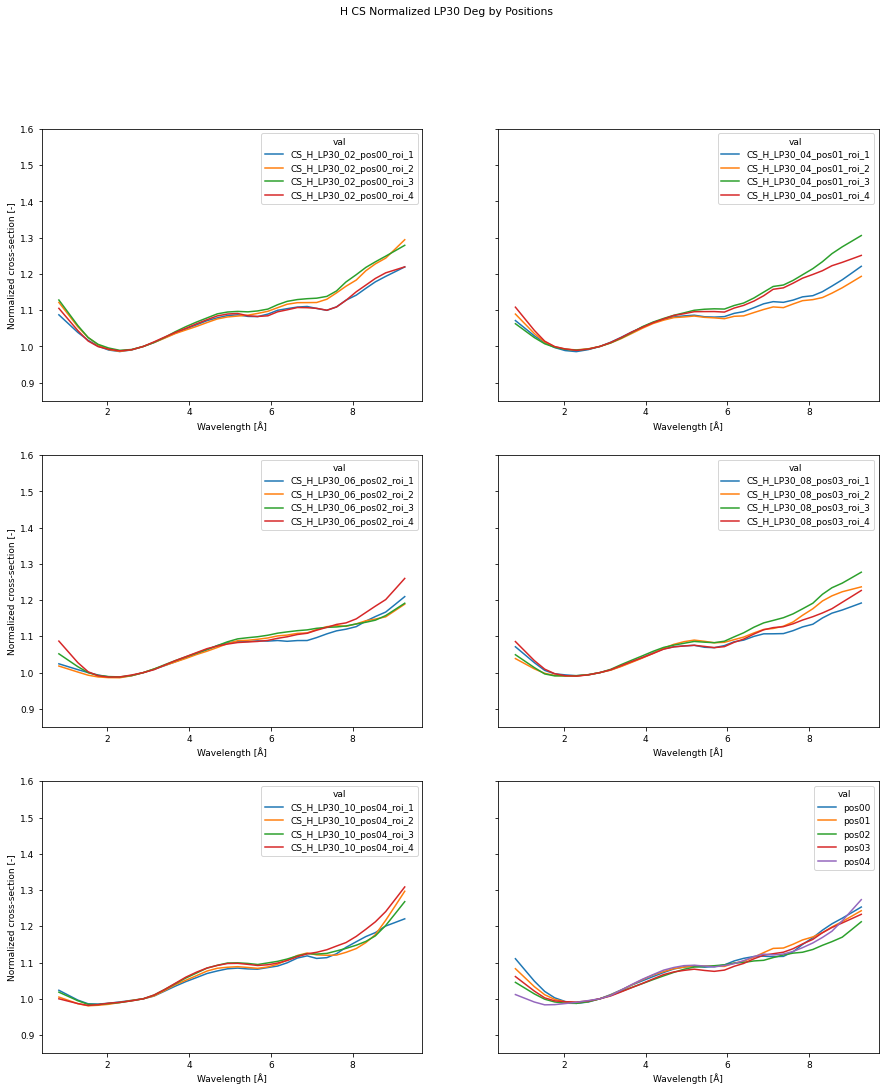

In [31]:
fig1, ax = plt.subplots(3,2, figsize = (15,17), sharey = True)
fig1.suptitle('H CS Normalized LP30 Deg by Positions')
#ax[0,0].set_title('Pos00')
plt.ylim([0.85,1.6])
sns.lineplot(ax = ax[0,0], data = cs_pos00_norm, x = 'Wavelength [Å]', y = 'Normalized cross-section [-]', hue = 'val')
sns.lineplot(ax = ax[0,1], data = cs_pos01_norm, x = 'Wavelength [Å]', y = 'Normalized cross-section [-]', hue = 'val')
sns.lineplot(ax = ax[1,0], data = cs_pos02_norm, x = 'Wavelength [Å]', y = 'Normalized cross-section [-]', hue = 'val')
sns.lineplot(ax = ax[1,1], data = cs_pos03_norm, x = 'Wavelength [Å]', y = 'Normalized cross-section [-]', hue = 'val')
sns.lineplot(ax = ax[2,0], data = cs_pos04_norm, x = 'Wavelength [Å]', y = 'Normalized cross-section [-]', hue = 'val')
sns.lineplot(ax = ax[2,1], data = avg_vals_norm, x = 'Wavelength [Å]', y = 'Normalized cross-section [-]', hue = 'val')

In [32]:
res_data_PEn3Anorm

,Wavelength [Å],CS_H_LP30_02_pos00_roi_1,CS_H_LP30_02_pos00_roi_2,CS_H_LP30_02_pos00_roi_3,CS_H_LP30_02_pos00_roi_4,CS_H_LP30_04_pos01_roi_1,CS_H_LP30_04_pos01_roi_2,CS_H_LP30_04_pos01_roi_3,CS_H_LP30_04_pos01_roi_4,CS_H_LP30_06_pos02_roi_1,...,CS_H_LP30_06_pos02_roi_3,CS_H_LP30_06_pos02_roi_4,CS_H_LP30_08_pos03_roi_1,CS_H_LP30_08_pos03_roi_2,CS_H_LP30_08_pos03_roi_3,CS_H_LP30_08_pos03_roi_4,CS_H_LP30_10_pos04_roi_1,CS_H_LP30_10_pos04_roi_2,CS_H_LP30_10_pos04_roi_3,CS_H_LP30_10_pos04_roi_4
0,1.273682,1.087244,1.121430,1.128150,1.105101,1.071379,1.089287,1.062695,1.108339,1.024221,...,1.051808,1.086926,1.071233,1.038621,1.049275,1.085630,1.023445,1.004705,1.018211,0.999861
1,1.529439,1.062991,1.087856,1.092959,1.074432,1.050327,1.062456,1.043536,1.076297,1.016188,...,1.034087,1.057253,1.049339,1.024475,1.031544,1.059351,1.009866,0.995584,1.006383,0.993264
2,1.785196,1.038737,1.054281,1.057767,1.043763,1.029275,1.035625,1.024377,1.044256,1.008154,...,1.016366,1.027581,1.027444,1.010329,1.013813,1.033073,0.996286,0.986462,0.994554,0.986667
3,2.048178,1.016895,1.024463,1.024595,1.014996,1.010416,1.012128,1.007372,1.014563,1.000092,...,0.999935,1.002264,1.006085,0.997993,0.996311,1.009543,0.986051,0.980639,0.984624,0.981483
4,2.318891,1.000883,1.004161,1.005728,0.999390,0.996914,0.999093,0.997587,0.999599,0.993241,...,0.992172,0.991199,0.996663,0.992242,0.990899,0.996924,0.985317,0.981987,0.983916,0.983786
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
30,8.799547,1.160417,1.208951,1.218123,1.169338,1.151087,1.134857,1.233826,1.208963,1.142092,...,1.138888,1.165944,1.150723,1.197554,1.216071,1.164550,1.171668,1.155062,1.158236,1.191851
31,9.038885,1.178200,1.227764,1.233473,1.187616,1.166495,1.146959,1.255936,1.222678,1.154604,...,1.144637,1.183314,1.163977,1.211778,1.234082,1.176206,1.182541,1.176880,1.173519,1.212247
32,9.279254,1.193277,1.243656,1.249106,1.203072,1.183960,1.161863,1.274840,1.232008,1.167072,...,1.157353,1.201433,1.172702,1.223053,1.246878,1.194012,1.200705,1.216513,1.202195,1.240558
33,9.519003,1.206335,1.269057,1.264078,1.211306,1.202524,1.177619,1.290408,1.241584,1.188359,...,1.174371,1.230635,1.182338,1.229800,1.261940,1.210305,1.210634,1.256573,1.235067,1.274531
